In [133]:
#1. Librerías.
# !pip install matplotlib
# !pip install seaborn
# !pip install unidecode
# !pip install rapidfuzz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import re
import unidecode
from rapidfuzz import process, fuzz
import os
import json
import re
import pandas as pd
import unicodedata

In [134]:
#2. Constantes.
path = "C:/Users/leopo/Desktop/Maestria DATA MINING/TEXT MINING/TP/post-procesamiento/"
df_final_path = path + "df_final_crudo.csv"
df_exportacion_path = path + "df_final_limpio.csv"

In [135]:
#3. Lectura.
df_final = pd.read_csv(df_final_path)
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None) 

C:\Users\leopo\AppData\Local\Temp\ipykernel_31864\855688390.py:2: DtypeWarning:

Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.



In [136]:
#4. El LLM creó en algunos casos columnas incorrectas ----> Reemplazo los valores obtenidos en sus columnas correspondientes.
#a. Reemplazo los valores.
df_final.loc[~df_final["impact_fmi"].isna(),"impacto_fmi"] = df_final.loc[~df_final["impact_fmi"].isna()]["impact_fmi"]
df_final.loc[~df_final["menciona_sector_agroexportador "].isna(),"menciona_sector_agroexportador"] = df_final.loc[~df_final["menciona_sector_agroexportador "].isna()]["menciona_sector_agroexportador "]
df_final.loc[~df_final["activid(ad)_económica"].isna(),"actividad_economica"] = df_final.loc[~df_final["activid(ad)_económica"].isna()]["activid(ad)_económica"]
df_final.loc[~df_final["impact_prestamos_internacionales"].isna(),"impacto_prestamos_internacionales"] = df_final.loc[~df_final["impact_prestamos_internacionales"].isna()]["impact_prestamos_internacionales"]
#b. Elimino las columnas correspondientes.
df_final.drop(columns=["impact_fmi","menciona_sector_agroexportador ","activid(ad)_económica","impact_prestamos_internacionales"], inplace=True)

In [137]:
#5. Elimino aquellas noticias sin contenido (vacío).
df_final = df_final[~df_final["contenido"].isna()]

In [138]:
#6. Normalización de columnas de "texto libre".
#a. Formateo.
df_final["sectores_mencionados"] = df_final["sectores_mencionados"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_final["empresas_mencionadas"] = df_final["empresas_mencionadas"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_final["tickers_mencionados"] = df_final["tickers_mencionados"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
#b. Normalizo los sectores.
def normalizar_strings(s):
    s = s.lower().strip() # minúsculas.
    s = unidecode.unidecode(s)  # quita tildes.
    s = s.replace("_", " ").replace("-", " ").replace("/", " ").strip() # reemplazo valores.
    # Eliminar puntos, comas y otros signos (excepto letras, números y espacios)
    s = re.sub(r"[^a-z0-9áéíóúüñ\s]", "", s)
    s = s.replace("(", " ").replace(")", " ")
    return s

def normalizar_sector_macro(string):
    if not isinstance(string, str):
        return string

    s = normalizar_strings(string)

    # Macro-sectores
    if re.search(r'finan|banca|bono|mercado|fondos|deposito|inversion', s):
        return 'Finanzas'
    if re.search(r'cripto|blockchain|nft|defi|fintech', s):
        return 'Cripto / Fintech'
    if re.search(r'tecnolog|software|data|inteligencia|robot|semiconductor|iot|ia', s):
        return 'Tecnología'
    if re.search(r'energ|petroleo|gas|renovable|gnl|electrico|electricidad', s):
        return 'Energía'
    if re.search(r'min', s) and not 'admin' in s:
        return 'Minería'
    if re.search(r'educa|universidad|escuela|formacion|capacita', s):
        return 'Educación'
    if re.search(r'salud|medic|farmaceut|hospital', s):
        return 'Salud'
    if re.search(r'comerc|retail|supermercado|consumo|alimentos|bebid|frigorif', s):
        return 'Comercio / Consumo'
    if re.search(r'transport|logistic|puerto|aero|hidro|movilidad|vehiculos', s):
        return 'Transporte / Logística'
    if re.search(r'gobier|sector publico|administracion|municipal|provincial', s):
        return 'Gobierno / Sector Público'
    if re.search(r'politi|electoral|legislativ|partid', s):
        return 'Política'
    if re.search(r'justic|judicial|tribunal|juridic', s):
        return 'Justicia'
    if re.search(r'segur', s):
        return 'Seguridad'
    if re.search(r'turism|viaje|hotel|balneario|turistico', s):
        return 'Turismo'
    if re.search(r'industri|manufactur|fabrica|metal|quimic|textil|automotriz', s):
        return 'Industria / Manufactura'
    if re.search(r'agro|ganad|rural|agric|cultivo|frut|soja|maiz|trigo', s):
        return 'Agropecuario'
    if re.search(r'inmob|vivienda|constru|obra', s):
        return 'Construcción / Inmobiliario'
    if re.search(r'medio ambiente|ambient|ecolog|forest', s):
        return 'Medio Ambiente'
    if re.search(r'emple|laboral|trabaj', s):
        return 'Empleo / Laboral'
    if re.search(r'servic', s):
        return 'Servicios'
    if re.search(r'infraestr|hidrovía|hidrovia', s):
        return 'Infraestructura'
    
    # Si no entra en ninguna categoría
    return 'Otros'

df_final["sectores_mencionados"] = df_final["sectores_mencionados"].apply(
    lambda lista: list(dict.fromkeys([normalizar_sector_macro(s) for s in lista])) 
    if isinstance(lista, list) else lista
)

#c. Normalizo nombre de actor principal.
#i. Unifico caracteres.
df_final["nombre_actor_principal"] = df_final["nombre_actor_principal"].apply(
    lambda x: normalizar_strings(x) if isinstance(x, str) else x
)
#ii. Unifico actores que se pueden escribir igual.
mapa_actores = {
    # Javier Milei
    "gobierno de javier milei": "javier milei",
    "gobierno nacional (javier milei)": "javier milei",
    "gobierno   javier milei": "javier milei",
    "gobierno (javier milei)": "javier milei",
    "gobierno nacional (presidente javier milei)": "javier milei",
    # Gobierno Nacional general
    "gobierno argentino": "gobierno nacional",
    # Banco Central
    "banco central": "banco central de la republica argentina bcra",
    "banco central de la republica argentina": "banco central de la republica argentina bcra",
    "banco central de la republica argentina (bcra)": "banco central de la republica argentina bcra",
    "bcra": "banco central de la republica argentina bcra",
    "banco central (santiago bausili)": "banco central de la republica argentina bcra)",
    # ANSES
    "anses": "administracion nacional de la seguridad social",
    # FMI / Fondo Monetario
    "fmi": "fondo monetario internacional",
    # Cristina Kirchner
    "cristina kirchner": "cristina fernandez de kirchner",
    "cfk": "cristina fernandez de kirchner", #agrego
    "cristina fernandez de kirchner": "cristina fernandez de kirchner",
    # Luis Caputo
    "luis \"toto\" caputo": "luis caputo",
    "ministerio de economia   luis caputo": "luis caputo",
    "ministerio de economia (luis caputo)": "luis caputo",
    # Otros actores grandes.",
    "banco de la nacion argentina": "banco nacion",
    "bna": "banco nacion", #agrego

}
#iii. Aplico.
def unificar_actores(actor):
    if not isinstance(actor, str):
        return actor
    actor = mapa_actores.get(actor, actor)  # si está en el mapa, reemplaza
    return actor

df_final["nombre_actor_principal"] = df_final["nombre_actor_principal"].apply(unificar_actores)


#d. Normalizo empresas mencionadas.
#i. Unifico caracteres.
df_final["empresas_mencionadas"] = df_final["empresas_mencionadas"].apply(
    lambda lista: [normalizar_strings(s) for s in lista] if isinstance(lista, list) else lista
)

mapa_empresas = {
    # Javier Milei
    "bcra": "banco central de la republica argentina bcra",
    "banco central bcra": "banco central de la republica argentina bcra",
    "banco central": "banco central de la republica argentina bcra",
    "banco central de la republica argentina (bcra)": "banco central de la republica argentina bcra",
    "banco nacion": "banco nacion",
    "banco de la nacion argentina": "banco nacion",
    "bna": "banco nacion",

}

def unificar_empresas(lista):
    if isinstance(lista, list):
        return [mapa_empresas.get(s, s) for s in lista]
    return lista

#3. Aplico.
df_final["empresas_mencionadas"] = df_final["empresas_mencionadas"].apply(unificar_empresas)


In [139]:
#7. Analizo los valores únicos por columna.
#i. Sectores mencionales.
todos_los_sectores = [s for lista in df_final["sectores_mencionados"] for s in lista]
sectores_unicos = sorted(set(todos_los_sectores))
print("La cantidad de sectores post-procesamiento es de {}".format(len(sectores_unicos)))
#ii. Empresas mencionadas.
todas_las_empresas = [s for lista in df_final["empresas_mencionadas"] for s in lista]
empresas_unicas = sorted(set(todas_las_empresas))
print("La cantidad de empresas es de {}".format(len(empresas_unicas)))
#iii. Tickers mencionados.
todos_los_tickers = [s for lista in df_final["tickers_mencionados"] for s in lista]
tickers_unicos = sorted(set(todos_los_tickers))
print("La cantidad de tickers es de {}".format(len(tickers_unicos)))
#iv. Tipo de actor principal.
tipo_actor_principal_unicos = df_final["tipo_actor_principal"].unique()
print("La cantidad de tipo de actores principales es de {}".format(len(tipo_actor_principal_unicos)))
#v. Actor principal.
actor_principal = df_final["nombre_actor_principal"].unique()
print("La cantidad de actores principales es de {}".format(len(actor_principal)))
#vi. Caracter.
caracters_unicos = df_final["caracter"].unique()
print("La cantidad de caracteres es de {}".format(len(caracters_unicos)))
#vii. Shock.
shock_unicos = df_final["shock"].unique()
print("La cantidad de shock es de {}".format(len(shock_unicos)))
#viii. Tipo Evento.
tipo_evento_unicos = df_final["tipo_evento"].unique()
print("La cantidad de tipo de evento es de {}".format(len(tipo_evento_unicos)))

La cantidad de sectores post-procesamiento es de 22
La cantidad de empresas es de 8247
La cantidad de tickers es de 456
La cantidad de tipo de actores principales es de 12
La cantidad de actores principales es de 3019
La cantidad de caracteres es de 4
La cantidad de shock es de 5
La cantidad de tipo de evento es de 12


In [140]:
#8. Para las listas de empresas, agarro las 10 con mayor frecuencia y con esas hago dummies.
#a. Saco el top 10.
top10 = (
    df_final.explode("empresas_mencionadas")["empresas_mencionadas"]
    .value_counts()
    .head(10)
    .index.tolist()
)


#b. Columna dummy.
for emp in top10:
    df_final[f"emp_{emp}"] = df_final["empresas_mencionadas"].apply(
        lambda lista: int(emp in lista if isinstance(lista, list) else False)
    )

In [141]:
#9. Para los actores principales, normalizo los nombres, agrupo los que son equivalentes (por similitud textual), y luego crear variables dummies para los 10 actores más frecuentes.
#a. Función para normalizar.
def generar_diccionario_sugerencias(
    lista_elementos,
    nombre_salida="sugerencias",
    umbral=75,
    limite=10,
    min_longitud=7,
    filtrar_multiples = False
):
    """
    Genera un diccionario de normalización basado en similitud textual (RapidFuzz).
      ✅ Ignora palabras cortas (≤ min_longitud - 1)
      ✅ Elimina stopwords genéricas
      ✅ Ignora frases geográficas comunes (p.ej. "provincia de buenos aires")
      ✅ Exige similitud de palabras (Jaccard >= 0.4) y >= 2 palabras exactas en común
      ✅ Evita cruzar entidades de distinto dominio ("banco", "partido", "ministerio", etc.)
      ✅ Prioriza nombres sin paréntesis
      ✅ Elimina duplicados, aplica transitividad, y ordena alfabéticamente
      Si filtrar_multiple, entonces intenta quedarse con un solo actor cuando hay varios
    """

    print(f"🧩 Generando diccionario para '{nombre_salida}'...")

    # --- Configuración ---
    STOPWORDS = {
        "administracion",  "grupo", "sociedad", "compania", "compañia",
        "canal", "plc", "sa", "s.a", "s.a.", "sac", "corp", "company", "inc",
        "holding", "cooperativa", "cooperativo", "union", "universidad", "capital", "ventures", "holding", "ltd", "news",
        "instituto", "argentina", "grupo", "fundacion", "federacion", "ente", "empresa", "investment", "direccion",
        "departamento", "consultora", "corporacion", "consejo", "consorcio", "confederacion", "camara", "comision", "centro", "group",
        "nacional", "decreto", "justicia", "federal", "ministerio","mesa", "enlace", "municipalidad", "municipio", "oficina",
        "productores", "bolsa", "markets", "transportadora", "secretaria", "mercado", "sindicato", "supermercados"


    }


    FRASES_COMUNES = [
        "provincia de ",
        "ciudad de ",
        "republica argentina",
        " de valores",                  
        "mercado bursatil ",  
        "union industrial ",
        "union argentina ",
        "asset management", "corte suprema de justicia de", 
        "gobierno de estados unidos ", 
        "gobierno de"
        "tribunal oral "
        "banco de "
    ]

    # no mezcla palabras de diferentes dominios
    DOMINIOS = {
        "banco", "bolsa", "mercado", "caja", "comision", "ministerio",
        "partido", "universidad", "secretaria",
        "policia", "direccion", "legislatura",
        "camara", "federacion", 
        "asociacion", "empresa", "cooperativa", "corte suprema de justicia de ", 
        "tribunal oral ", "union", "karina ", "javier ", "banco galicia ", "corea", "sindicato", "supermercados", "brasil"
    }

    # --- FUNCIONES AUXILIARES ---
    def limpiar_stopwords(texto):
        palabras = [p for p in texto.split() if p.lower() not in STOPWORDS]
        return " ".join(palabras)

    def limpiar_frases_comunes(texto):
        texto = texto.lower()
        for frase in FRASES_COMUNES:
            texto = texto.replace(frase, "")
        return texto.strip()

    def palabras_en_comun(a, b):
        set_a = set(a.split())
        set_b = set(b.split())
        return len(set_a & set_b)

    def similitud_palabras(a, b):
        set_a, set_b = set(a.split()), set(b.split())
        if not set_a or not set_b:
            return 0
        inter = len(set_a & set_b)
        union = len(set_a | set_b)
        return inter / union  # índice de Jaccard

    def tipo_entidad(nombre):
        nombre_lower = nombre.lower()
        for d in DOMINIOS:
            if d in nombre_lower:
                return d
        return "otro"


    def tomar_primer_actor(texto):
        # si hay 2 actores quedarme con el primero
        return re.split(r"\b(?:y|&|con)\b|\s{3,}", texto, maxsplit=1)[0].strip()
    

    # --- 1. Contar frecuencias ---
    conteo = pd.Series(lista_elementos).value_counts()
    items = [i for i in conteo.index if len(i.strip()) >= min_longitud]
    print(f"Filtradas {len(conteo) - len(items)} entradas cortas (≤ {min_longitud - 1} caracteres).")

    # --- 2. Buscar coincidencias ---
    pairs = {}
    for e in items:
        e_original = e
        if filtrar_multiples:
            e = tomar_primer_actor(e)
        e_clean = limpiar_stopwords(limpiar_frases_comunes(e))
        similares = process.extract(
            e_clean, [limpiar_stopwords(limpiar_frases_comunes(i)) for i in items],
            scorer=fuzz.token_sort_ratio, limit=limite
        )

        tipo_e = tipo_entidad(e)

        for s_clean, score, idx in similares:
            s = items[idx]
            if s == e or score < umbral:
                continue

            tipo_s = tipo_entidad(s)
            if tipo_e != tipo_s and not (tipo_e == "otro" or tipo_s == "otro"):
                # evitar cruces entre dominios distintos
                continue

            if palabras_en_comun(e, s) < 2:
                continue
            if similitud_palabras(e, s) < 0.4:
                continue

            # Clave ordenada para evitar duplicados
            key = tuple(sorted([e, s]))

            # Priorizar el que no tiene paréntesis
            freq_e = conteo.get(e, 0)
            freq_s = conteo.get(s, 0)
            canonico = e if freq_e >= freq_s else s
            variante = s if canonico == e else e

            if key not in pairs or score > pairs[key]["score"]:
                pairs[key] = {"variante": variante, "canonico": canonico, "score": score}

    # --- 3. Crear diccionario plano ---
    diccionario = {r["variante"]: r["canonico"] for r in pairs.values()}

    # --- 4. Resolver transitividad ---
    def resolver_transitividad(dic):
        def find_root(x, seen=None):
            if seen is None:
                seen = set()
            if x not in dic or x in seen:
                return x
            seen.add(x)
            return find_root(dic[x], seen)

        resultado = {}
        for k, v in dic.items():
            root = find_root(v)
            resultado[k] = root
        return resultado

    diccionario_final = resolver_transitividad(diccionario)

    # --- 5. Ordenar alfabéticamente ---
    diccionario_ordenado = dict(
        sorted(diccionario_final.items(), key=lambda x: (x[1].lower(), x[0].lower()))
    )

    # --- 6. Guardar resultado ---
    carpeta_salida = "./dicts"
    os.makedirs(carpeta_salida, exist_ok=True)

    output_path = os.path.join(carpeta_salida, f"sugerencias_{nombre_salida}.json")
    with open(output_path, "w", encoding="utf8") as f:
        json.dump(diccionario_ordenado, f, ensure_ascii=False, indent=2)

    print(f"✅ Diccionario '{nombre_salida}' guardado en {output_path} con {len(diccionario_ordenado)} entradas.")
    return diccionario_ordenado
#b. Genero diccionario buscando similares con la logica de generar_diccionario_sugerencias.
dicc_actor = generar_diccionario_sugerencias(df_final["nombre_actor_principal"].unique(), nombre_salida="actor_principal", filtrar_multiples=True)

#c. Sigo normalizando.
def aplicar_mapa(df, columna, mapa):
    """
    Reemplaza valores en strings o listas dentro de columna
    usando diccionario exacto {variante: canonico} sin normalizar.
    """
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    def mapear_uno(x):
        if x is None:
            return x
        # si es string
        if isinstance(x, str):
            return mapa.get(x, x)
        # si es lista / tuple / set
        if isinstance(x, (list, tuple, set)):
            t = type(x)
            mapped = [mapear_uno(e) for e in x]
            if t is set: return set(mapped)
            if t is tuple: return tuple(mapped)
            return mapped   # list
        return x

    out = df.copy()
    out[columna] = out[columna].apply(mapear_uno)
    return out

df_final = aplicar_mapa(df_final, "nombre_actor_principal", dicc_actor)

#d. Habiendo ya unificado algo los actores, tomo el top 10, hago dummies y los remuevo de los string originales.
# 1) separador robusto para partir actores dentro del string original
pat_split = re.compile(r"\s{3,}|\s+y\s+|[,;/]")

def split_actores(val: str):
    if not isinstance(val, str) or not val.strip():
        return []
    partes = pat_split.split(val)
    return [p.strip() for p in partes if p.strip()]

# 2) top 10 actores (a partir del string, sin normalizar)
df_final["__actores_lista"] = df_final["nombre_actor_principal"].apply(split_actores)
top10_actores = (
    df_final["__actores_lista"].explode().value_counts().head(10).index.tolist()
)

# 3) regex para detectar y eliminar (ordenar por longitud desc evita matches parciales primero)
actores_ordenados = sorted(top10_actores, key=len, reverse=True)
alternativas = "|".join(re.escape(a) for a in actores_ordenados)
# palabra/frase completa: límites de palabra a ambos lados (maneja multi-palabra igual)
pat_remove = re.compile(rf"\b(?:{alternativas})\b")

# 4) dummies por presencia (match como palabra/frase completa en el string)
def has_actor(s: str, actor: str) -> int:
    if not isinstance(s, str) or not s.strip():
        return 0
    return int(re.search(rf"\b{re.escape(actor)}\b", s) is not None)

# nombres de columna seguros
def slug(s: str, maxlen=60):
    s2 = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s2 = re.sub(r"[^A-Za-z0-9]+", "_", s2).strip("_").lower()
    return s2[:maxlen]

for actor in top10_actores:
    col = f"act_{slug(actor)}"
    df_final[col] = df_final["nombre_actor_principal"].apply(lambda s: has_actor(s, actor))


# limpiar columna auxiliar
df_final.drop(columns=["__actores_lista"], inplace=True)

🧩 Generando diccionario para 'actor_principal'...
Filtradas 229 entradas cortas (≤ 6 caracteres).
✅ Diccionario 'actor_principal' guardado en ./dicts\sugerencias_actor_principal.json con 644 entradas.


In [142]:
#10. Creo nuevas columnas booleanas con True o False según aparición.
conteo_tickers = pd.Series(todos_los_tickers).value_counts()
top_tickers = list(conteo_tickers.head(10).keys())

for ticker in top_tickers:
    df_final[f'ticker_{ticker}'] = df_final['tickers_mencionados'].apply(lambda x: ticker in x)

for sector in sectores_unicos:
    df_final[f'sector_{sector}'] = df_final['sectores_mencionados'].apply(lambda x: sector in x)

for actor in tipo_actor_principal_unicos:
    df_final[f'tipo_actor_principal_{actor}'] = df_final['tipo_actor_principal'].apply(lambda x: actor in x)

for caracter in caracters_unicos:
    df_final[f'caracter_{caracter}'] = df_final['caracter'].apply(lambda x: caracter in x)

for shock in shock_unicos:
    df_final[f'shock_{shock}'] = df_final['shock'].apply(lambda x: shock in x)

for tipo_evento in tipo_evento_unicos:
    df_final[f'tipo_evento_{tipo_evento}'] = df_final['tipo_evento'].apply(lambda x: tipo_evento in x)

In [143]:
#11. Nuevas columnas con extensión de la lista.
df_final['cant_empresas'] = df_final['empresas_mencionadas'].apply(len)
df_final['cant_tickers'] = df_final['tickers_mencionados'].apply(len)
df_final['cant_sectores'] = df_final['sectores_mencionados'].apply(len)

In [144]:
#12. Nuevas columnas con la extensión de la noticia.
df_final['palabras_titulo'] = df_final['titulo'].apply(lambda x: len(str(x).split()))
df_final['palabras_noticia'] = df_final['contenido'].apply(lambda x: len(str(x).split()))

In [145]:
#13. Creo columna booleana con el nombre del diario y la sección.
diarios_unicos = df_final["diario"].unique()

for diario in diarios_unicos:
    df_final[f'diario_{diario}'] = df_final['diario'].apply(lambda x: diario in x)

In [146]:
#14. Creo columna booleano con la categoria fuente.
categoria_fuente_unicas = df_final["categoria_fuente"].unique()

for categoria in categoria_fuente_unicas:
    df_final[f'categoria_fuente_{categoria}'] = df_final['categoria_fuente'].apply(lambda x: categoria in x)


In [147]:
#15. Elimino las columnas que ya no voy a tener en cuenta.
#a. Listado de columnas a eliminar.
columnas_a_eliminar = [
    'diario', 
    'titulo', 
    'contenido', 
    'url', 
    'seccion', 
    'tipo_actor_principal', 
    'nombre_actor_principal', 
    'empresas_mencionadas',
    'tickers_mencionados',
    'sectores_mencionados',
    'tipo_evento',
    'shock',
    'caracter',
    'categoria_fuente'
]

#b. Eliminación.
df_final = df_final.drop(columns=columnas_a_eliminar)

In [148]:
print("total_filas:",len(df_final))
df_final.isna().sum()[df_final.isna().sum()>0]

total_filas: 15197


horizonte_dias    13810
fx_usdars             7
fx_usd            15190
dtype: int64

In [149]:
#16. Relleno variables que quedaron con valores vacíos.
df_final["horizonte_dias"].fillna(-1,inplace=True)
df_final["fx_usdars"].fillna(0,inplace=True)
#Son la misma columna, convendra eliminar fx_uds que tiene todo 0
df_final.drop(columns=["fx_usd"], inplace=True)

In [150]:
#17. Chequeo tipo de datos de columnas
df_final.dtypes.value_counts()

bool       90
float64    29
int64      25
object      2
Name: count, dtype: int64

In [151]:
#18. Convierto fecha a fecha y menciona_sector_agroexportador a bool
df_final["fecha"] = pd.to_datetime(df_final["fecha"])
df_final["menciona_sector_agroexportador"] = df_final["menciona_sector_agroexportador"].astype(bool)

In [152]:
#Chequeo tipo de datos
df_final.dtypes.value_counts()

bool              91
float64           29
int64             25
datetime64[ns]     1
Name: count, dtype: int64

In [153]:
#19. Exporto.
#a. Dataset.
df_final = df_final.sort_values(by="fecha",ascending=True).reset_index(drop=True)
df_final.to_csv(df_exportacion_path,index=False)
#b. Columnas.
pd.Series(df_final.columns).to_csv("columnas_df_final.csv", index=False, header=False) #agrego header=False, se creaba una fila con 0

In [154]:
#20. Verificamos si quedó algun nulo en el dataset.
for col in df_final.columns:
    print(f"{col}: {df_final[col].isna().sum()}")

fecha: 0
horizonte_dias: 0
merval: 0
volatilidad_merval: 0
fx_usdars: 0
spread_usd: 0
tasa_bcra: 0
bonos_soberanos: 0
spread_bonos: 0
actividad_economica: 0
volumen_mercado: 0
valencia_general: 0
gobernanza: 0
expectativa_macro_corto: 0
expectativa_macro_largo: 0
expectativa_fin_corto: 0
expectativa_fin_largo: 0
menciona_inflacion: 0
menciona_pbi: 0
menciona_reservas: 0
menciona_embi: 0
menciona_deuda: 0
menciona_fmi: 0
menciona_salarios_paritarias: 0
menciona_tipo_cambio: 0
menciona_confianza_consumidor: 0
menciona_sector_bancario: 0
impacto_sector_bancario: 0
menciona_sector_energia: 0
impacto_sector_energia: 0
menciona_sector_agroexportador: 0
impacto_sector_agroexportador: 0
menciona_sector_industrial: 0
impacto_sector_industrial: 0
menciona_eeuu: 0
impacto_eeuu: 0
menciona_brasil: 0
impacto_brasil: 0
menciona_mercosur: 0
impacto_mercosur: 0
menciona_prestamos_internacionales: 0
impacto_prestamos_internacionales: 0
impacto_fmi: 0
menciona_commodities: 0
impacto_commodities: 0
menci

In [155]:
#21. Verificamos los tipos de datos de las columnas del dataset, buscando que no haya quedado ni listas ni categóricas.
pd.set_option('display.max_columns', None)
df_final.head(5)

,fecha,horizonte_dias,merval,volatilidad_merval,fx_usdars,spread_usd,tasa_bcra,bonos_soberanos,spread_bonos,actividad_economica,volumen_mercado,valencia_general,gobernanza,expectativa_macro_corto,expectativa_macro_largo,expectativa_fin_corto,expectativa_fin_largo,menciona_inflacion,menciona_pbi,menciona_reservas,menciona_embi,menciona_deuda,menciona_fmi,menciona_salarios_paritarias,menciona_tipo_cambio,menciona_confianza_consumidor,menciona_sector_bancario,impacto_sector_bancario,menciona_sector_energia,impacto_sector_energia,menciona_sector_agroexportador,impacto_sector_agroexportador,menciona_sector_industrial,impacto_sector_industrial,menciona_eeuu,impacto_eeuu,menciona_brasil,impacto_brasil,menciona_mercosur,impacto_mercosur,menciona_prestamos_internacionales,impacto_prestamos_internacionales,impacto_fmi,menciona_commodities,impacto_commodities,menciona_bolsa_extranjera,impacto_bolsa_extranjera,score_fuente,confianza,emp_banco nacion,emp_binance,emp_bitso,emp_lemon,emp_ypf,emp_banco central de la republica argentina bcra,emp_jp morgan,emp_mercado libre,emp_bbc,emp_la nacion,act_javier_milei,act_desconocido,act_banco_central_de_la_republica_argentina_bcra,act_gobierno_nacional,act_administracion_de_donald_trump,act_anses_administracion_nacional_de_seguridad_social,act_luis_caputo,act_fondo_monetario_internacional_directorio,act_gobierno,act_indec,ticker_AL30,ticker_BTC,ticker_LIBRA,ticker_ETH,ticker_SOL,ticker_BNB,ticker_ADA,ticker_AVAX,ticker_AL30D,ticker_LINK,sector_Agropecuario,sector_Comercio / Consumo,sector_Construcción / Inmobiliario,sector_Cripto / Fintech,sector_Educación,sector_Empleo / Laboral,sector_Energía,sector_Finanzas,sector_Gobierno / Sector Público,sector_Industria / Manufactura,sector_Infraestructura,sector_Justicia,sector_Medio Ambiente,sector_Minería,sector_Otros,sector_Política,sector_Salud,sector_Seguridad,sector_Servicios,sector_Tecnología,sector_Transporte / Logística,sector_Turismo,tipo_actor_principal_gobierno_nacional,tipo_actor_principal_empresa_extranjera,tipo_actor_principal_empresa_local,tipo_actor_principal_desconocido,tipo_actor_principal_provincia,tipo_actor_principal_sindicato,tipo_actor_principal_poder_judicial,tipo_actor_principal_municipio,tipo_actor_principal_congreso,tipo_actor_principal_organismo_internacional,tipo_actor_principal_bcra,tipo_actor_principal_externo,caracter_prospectivo,caracter_desconocido,caracter_retroactivo,caracter_vigente,shock_positivo,shock_desconocido,shock_negativo,shock_mixto,shock_neutro,tipo_evento_fiscal,tipo_evento_externo,tipo_evento_desconocido,tipo_evento_otro,tipo_evento_monetario,tipo_evento_corporativo,tipo_evento_judicial,tipo_evento_regulatorio,tipo_evento_sindical_social,tipo_evento_electoral,tipo_evento_analisis,tipo_evento_regulatory,cant_empresas,cant_tickers,cant_sectores,palabras_titulo,palabras_noticia,diario_Ámbito Financiero,diario_Clarín,diario_La Nación,diario_Pagina 12,categoria_fuente_periodistica,categoria_fuente_analisis,categoria_fuente_oficial
0,2025-01-01,-1.0,0.2,0.1,-0.2,-0.1,0.0,0.2,-0.2,0.1,0.1,0.6,0.5,0.3,0.4,0.2,0.3,True,True,False,True,False,False,False,False,False,True,-0.5,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,0.0,False,0.0,False,0.0,0.7,0.8,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,0,0,3,21,458,True,False,False,False,True,False,False
1,2025-01-01,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False,False,False,False,False,False,False,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False,0.0,0.0,False,0.0,False,0.0,0.6,0.2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [156]:
#22. Cantidad de columnas y filas totales.
df_final.shape

(15197, 146)

In [157]:
#23. Estadísticos básicos finales.
df_final.describe()

,fecha,horizonte_dias,merval,volatilidad_merval,fx_usdars,spread_usd,tasa_bcra,bonos_soberanos,spread_bonos,actividad_economica,volumen_mercado,valencia_general,gobernanza,expectativa_macro_corto,expectativa_macro_largo,expectativa_fin_corto,expectativa_fin_largo,impacto_sector_bancario,impacto_sector_energia,impacto_sector_agroexportador,impacto_sector_industrial,impacto_eeuu,impacto_brasil,impacto_mercosur,impacto_prestamos_internacionales,impacto_fmi,impacto_commodities,impacto_bolsa_extranjera,score_fuente,confianza,emp_banco nacion,emp_binance,emp_bitso,emp_lemon,emp_ypf,emp_banco central de la republica argentina bcra,emp_jp morgan,emp_mercado libre,emp_bbc,emp_la nacion,act_javier_milei,act_desconocido,act_banco_central_de_la_republica_argentina_bcra,act_gobierno_nacional,act_administracion_de_donald_trump,act_anses_administracion_nacional_de_seguridad_social,act_luis_caputo,act_fondo_monetario_internacional_directorio,act_gobierno,act_indec,cant_empresas,cant_tickers,cant_sectores,palabras_titulo,palabras_noticia
count,15197,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.00000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000,15197.000000
mean,2025-03-02 04:20:00.552740608,5.374811,-0.034251,0.154388,0.110275,0.092624,-0.001155,-0.024498,0.038093,-0.020664,0.069957,-0.065131,-0.079473,-0.080617,-0.020041,-0.073632,-0.017053,0.009489,0.012532,0.011687,-0.017754,-0.023225,-0.00178,-0.000803,0.035201,0.029272,0.009091,-0.013559,0.636603,0.720721,0.063631,0.041587,0.030203,0.027505,0.023162,0.018227,0.017569,0.016319,0.015595,0.014016,0.118313,0.098046,0.090413,0.085083,0.024215,0.023294,0.025663,0.016516,0.119497,0.013029,2.072185,0.259920,2.930381,14.028821,715.663420
min,2025-01-01 00:00:00,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-0.600000,-1.000000,-1.000000,-1.000000,-1.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,12.000000
25%,2025-02-02 00:00:00,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300000,-0.200000,-0.200000,0.000000,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,11.000000,410.000000
50%,2025-03-01 00:00:00,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,14.000000,616.000000
75%,2025-04-01 00:00:00,-1.000000,0.000000,0.300000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.0

## Clustering

In [158]:
#!pip install gower
import gower
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from datetime import datetime

# Suponé que tu DataFrame se llama 'df'

# 1️⃣ Preprocesamiento
# Convertir booleanos a 0/1
df = df_final.copy()
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Procesar la columna datetime: convertir a "días desde hoy"
date_cols = df.select_dtypes('datetime').columns
for col in date_cols:
    df[col] = (datetime.now() - df[col]).dt.days

# Escalar variables numéricas
num_cols = df.select_dtypes(['float64', 'int64']).columns
df[num_cols] = StandardScaler().fit_transform(df[num_cols])

In [159]:
# 2️⃣ Calcular distancia Gower
#gower_dist = gower.gower_matrix(df)

In [160]:
import numpy as np
#Exporto
# np.save(path + "/gower_dist.csv", gower_dist)
#Importo
gower_dist = np.load(path + "/gower_dist.csv.npy")

In [161]:
#!pip install umap-learn
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import umap
import pandas as pd
import numpy as np

# Configuraciones a explorar
linkages = ['average', 'complete']
n_neighbors_list = [5, 15, 30]
min_dist_list = [0.1, 0.3, 0.5]
n_clusters_list = [5, 7, 10]

# Guardamos etiquetas de clustering en un diccionario
clusterings = {}

for link in linkages:
    for n_clusters in n_clusters_list:
        cluster = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric='precomputed',
            linkage=link
        )
        labels = cluster.fit_predict(gower_dist)
        name = f"{link}_k{n_clusters}"
        clusterings[name] = labels

# Calcular ARI entre todas las combinaciones
combinaciones = []
nombres = list(clusterings.keys())

for i in range(len(nombres)):
    for j in range(i + 1, len(nombres)):
        ari = adjusted_rand_score(clusterings[nombres[i]], clusterings[nombres[j]])
        combinaciones.append({
            'modelo_1': nombres[i],
            'modelo_2': nombres[j],
            'ARI': ari
        })

resultados_df = pd.DataFrame(combinaciones)

# Calcular el ARI medio de cada configuración (consistencia general)
consistencia = (
    resultados_df.groupby('modelo_1')['ARI'].mean()
    .reset_index()
    .rename(columns={'ARI': 'ARI_promedio'})
    .sort_values('ARI_promedio', ascending=False)
)
print(consistencia)

      modelo_1  ARI_promedio
4  complete_k7      0.952720
3  complete_k5      0.940513
2   average_k7      0.335323
0  average_k10      0.115269
1   average_k5      0.058687


In [166]:
#Exporto el diccionario de clustering para evitar recomputar
# Guardar resultados (pickle + csv)
import pickle
import pandas as pd

# --- GUARDAR DICCIONARIO COMPLETO ---
with open(path + "clusterings.pkl", "wb") as f:
    pickle.dump(clusterings, f)


# --- GUARDAR TAMBIÉN EN CSV ---
# Convertimos el diccionario en un DataFrame (una columna por clustering)
clusters_df = pd.DataFrame(clusterings)

# Aseguramos mismo índice que el DataFrame original
clusters_df.index = df.index

# Guardamos a CSV
clusters_df.to_csv(path + "clusters_resultados.csv", index=False)

In [163]:
mejor_modelo = consistencia.iloc[0]['modelo_1']
print("Usando como referencia:", mejor_modelo)

ref_labels = clusterings[mejor_modelo]

# Comparar cada configuración con la referencia
comparaciones = []
for nombre, labels in clusterings.items():
    ari = adjusted_rand_score(ref_labels, labels)
    comparaciones.append({'modelo': nombre, 'ARI_vs_ref': ari})

comparaciones_df = pd.DataFrame(comparaciones).sort_values('ARI_vs_ref', ascending=False)
print(comparaciones_df)

Usando como referencia: complete_k7
         modelo  ARI_vs_ref
4   complete_k7    1.000000
3   complete_k5    0.964082
5  complete_k10    0.952720
2   average_k10    0.116109
1    average_k7    0.115803
0    average_k5    0.008217


In [164]:
#Creo columna asignando a cada observacion su cluster
df['complete_k7'] = clusterings["complete_k7"]

C:\Users\leopo\AppData\Local\Temp\ipykernel_31864\4140578578.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [165]:
#Exporto.
#a. Dataset.
df_final_clustering = df.sort_values(by="fecha",ascending=True).reset_index(drop=True)
df_final_clustering.to_csv(path + "df_final_limpio_clustering.csv",index=False)

In [124]:
df['complete_k7'].value_counts()

complete_k7
4    8894
0    3438
1     977
2     847
6     525
3     307
5     209
Name: count, dtype: int64

In [125]:
df.groupby('complete_k7').mean(numeric_only=True)

,fecha,horizonte_dias,merval,volatilidad_merval,fx_usdars,spread_usd,tasa_bcra,bonos_soberanos,spread_bonos,actividad_economica,volumen_mercado,valencia_general,gobernanza,expectativa_macro_corto,expectativa_macro_largo,expectativa_fin_corto,expectativa_fin_largo,menciona_inflacion,menciona_pbi,menciona_reservas,menciona_embi,menciona_deuda,menciona_fmi,menciona_salarios_paritarias,menciona_tipo_cambio,menciona_confianza_consumidor,menciona_sector_bancario,impacto_sector_bancario,menciona_sector_energia,impacto_sector_energia,menciona_sector_agroexportador,impacto_sector_agroexportador,menciona_sector_industrial,impacto_sector_industrial,menciona_eeuu,impacto_eeuu,menciona_brasil,impacto_brasil,menciona_mercosur,impacto_mercosur,menciona_prestamos_internacionales,impacto_prestamos_internacionales,impacto_fmi,menciona_commodities,impacto_commodities,menciona_bolsa_extranjera,impacto_bolsa_extranjera,score_fuente,confianza,emp_banco nacion,emp_binance,emp_bitso,emp_lemon,emp_ypf,emp_banco central de la republica argentina bcra,emp_jp morgan,emp_mercado libre,emp_bbc,emp_la nacion,act_javier_milei,act_desconocido,act_banco_central_de_la_republica_argentina_bcra,act_gobierno_nacional,act_administracion_de_donald_trump,act_anses_administracion_nacional_de_seguridad_social,act_luis_caputo,act_fondo_monetario_internacional_directorio,act_gobierno,act_indec,ticker_AL30,ticker_BTC,ticker_LIBRA,ticker_ETH,ticker_SOL,ticker_BNB,ticker_ADA,ticker_AVAX,ticker_AL30D,ticker_LINK,sector_Agropecuario,sector_Comercio / Consumo,sector_Construcción / Inmobiliario,sector_Cripto / Fintech,sector_Educación,sector_Empleo / Laboral,sector_Energía,sector_Finanzas,sector_Gobierno / Sector Público,sector_Industria / Manufactura,sector_Infraestructura,sector_Justicia,sector_Medio Ambiente,sector_Minería,sector_Otros,sector_Política,sector_Salud,sector_Seguridad,sector_Servicios,sector_Tecnología,sector_Transporte / Logística,sector_Turismo,tipo_actor_principal_gobierno_nacional,tipo_actor_principal_empresa_extranjera,tipo_actor_principal_empresa_local,tipo_actor_principal_desconocido,tipo_actor_principal_provincia,tipo_actor_principal_sindicato,tipo_actor_principal_poder_judicial,tipo_actor_principal_municipio,tipo_actor_principal_congreso,tipo_actor_principal_organismo_internacional,tipo_actor_principal_bcra,tipo_actor_principal_externo,caracter_prospectivo,caracter_desconocido,caracter_retroactivo,caracter_vigente,shock_positivo,shock_desconocido,shock_negativo,shock_mixto,shock_neutro,tipo_evento_fiscal,tipo_evento_externo,tipo_evento_desconocido,tipo_evento_otro,tipo_evento_monetario,tipo_evento_corporativo,tipo_evento_judicial,tipo_evento_regulatorio,tipo_evento_sindical_social,tipo_evento_electoral,tipo_evento_analisis,tipo_evento_regulatory,cant_empresas,cant_tickers,cant_sectores,palabras_titulo,palabras_noticia,diario_Ámbito Financiero,diario_Clarín,diario_La Nación,diario_Pagina 12,categoria_fuente_periodistica,categoria_fuente_analisis,categoria_fuente_oficial
complete_k7,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.027218,-0.037446,0.062402,0.173662,0.382031,0.353641,-0.056172,0.136046,-0.106635,0.162864,0.156927,0.078869,0.152059,0.054183,0.070136,0.058439,0.079423,0.234729,0.088714,0.212333,0.072135,0.265852,0.242874,0.040430,0.899942,0.009889,0.507563,0.081934,0.064572,-0.013760,0.182955,0.034990,0.105003,0.058652,0.214078,0.114272,0.109657,0.007849,0.006108,0.021494,0.235020,0.255531,0.248693,0.137580,0.010783,0.069517,0.096350,0.113460,0.541857,0.563916,0.418172,0.579810,0.079028,-0.105643,0.261648,0.063312,-0.110435,-0.118823,-0.025205,-0.133969,0.540816,0.710159,0.020315,-0.136717,-0.152505,0.087872,-0.036021,-0.015093,-0.099505,0.089878,0.034322,0.016289,0.004072,0.002327,0.000291,0.000291,0.000000,0.035195,0.000000,0.124491,0.096859,0.019197,0.258581,0.006108,0.007853,0.017161,0.867656,0.092205,0.037522,0.010180,0.002327,0.000873,

C:\Users\leopo\AppData\Local\Temp\ipykernel_31864\3674361010.py:21: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



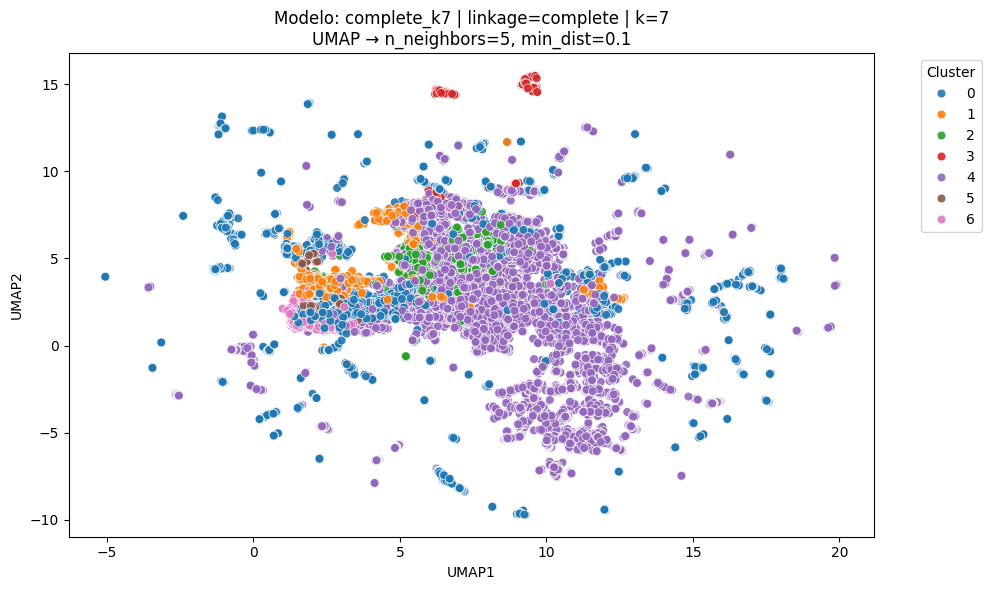

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



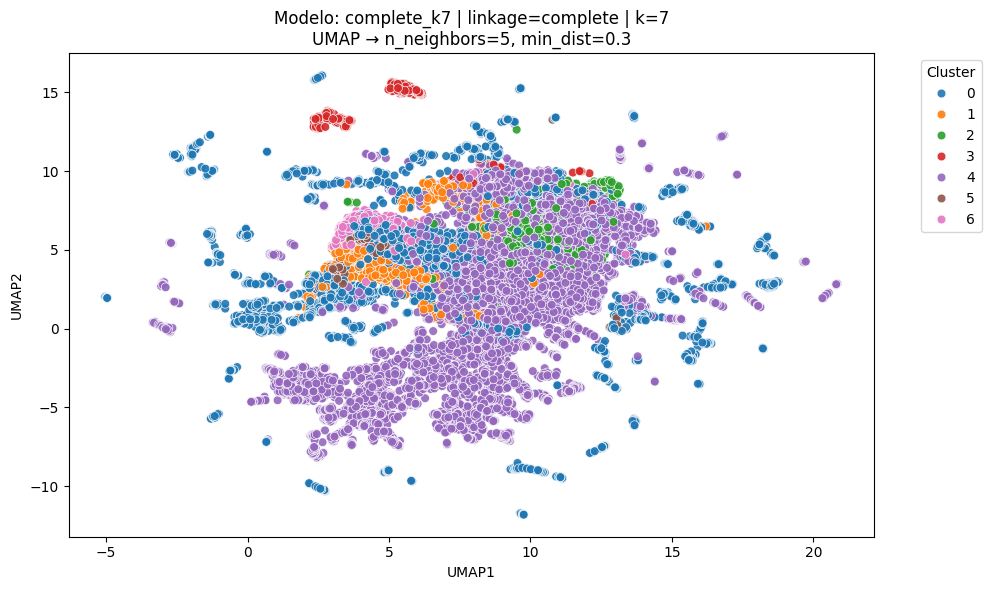

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



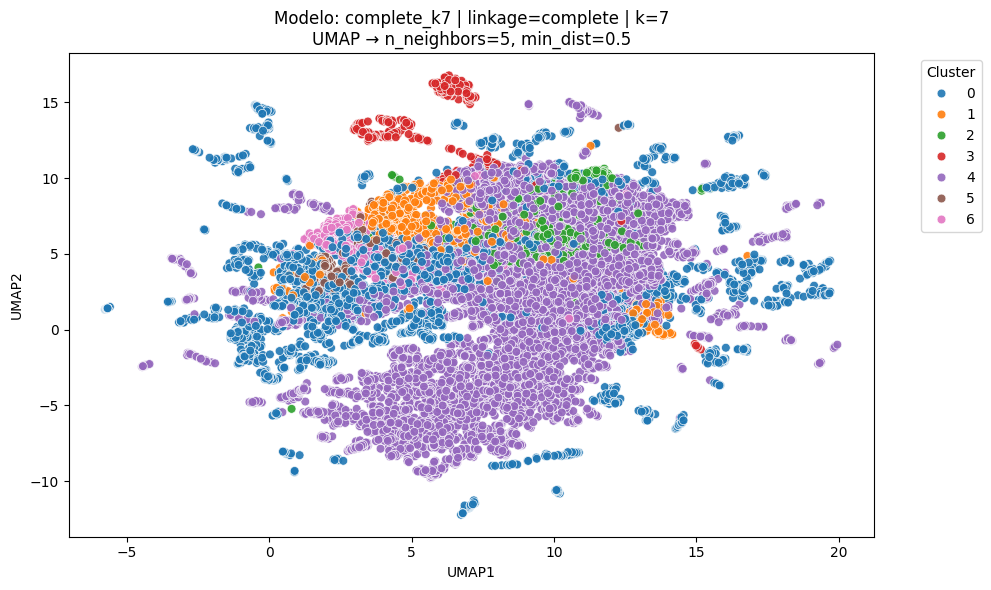

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



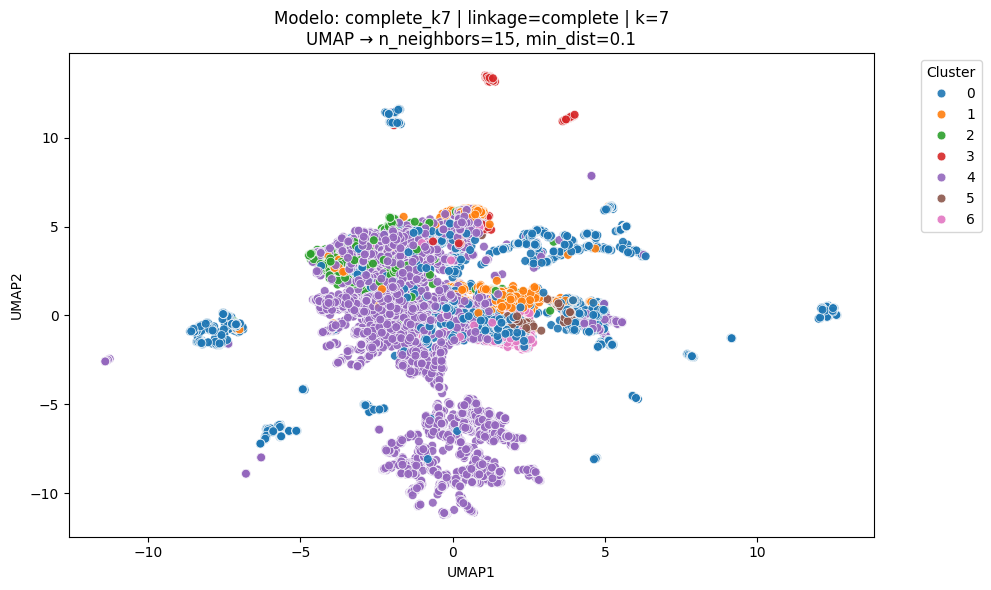

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



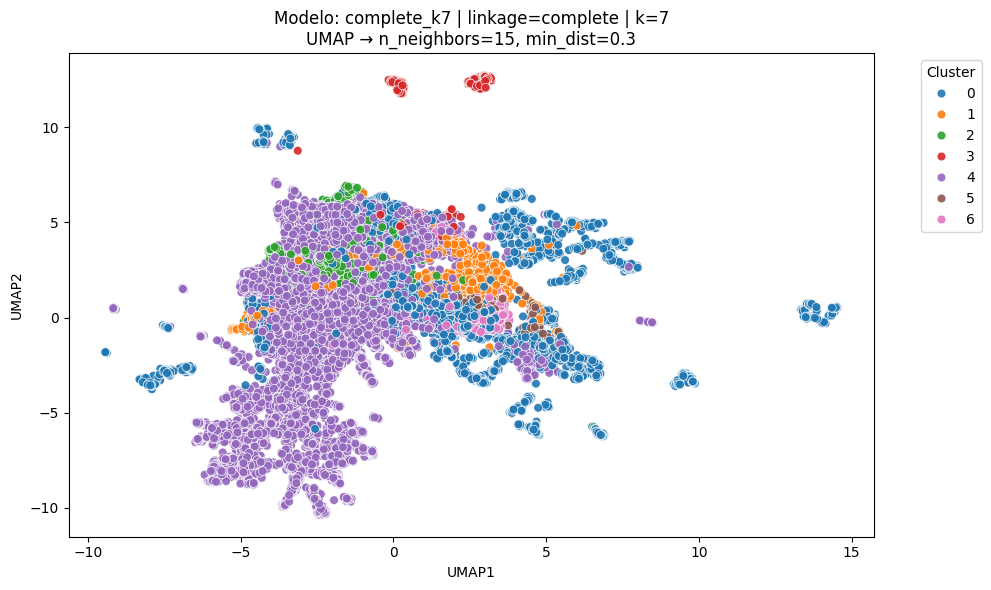

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



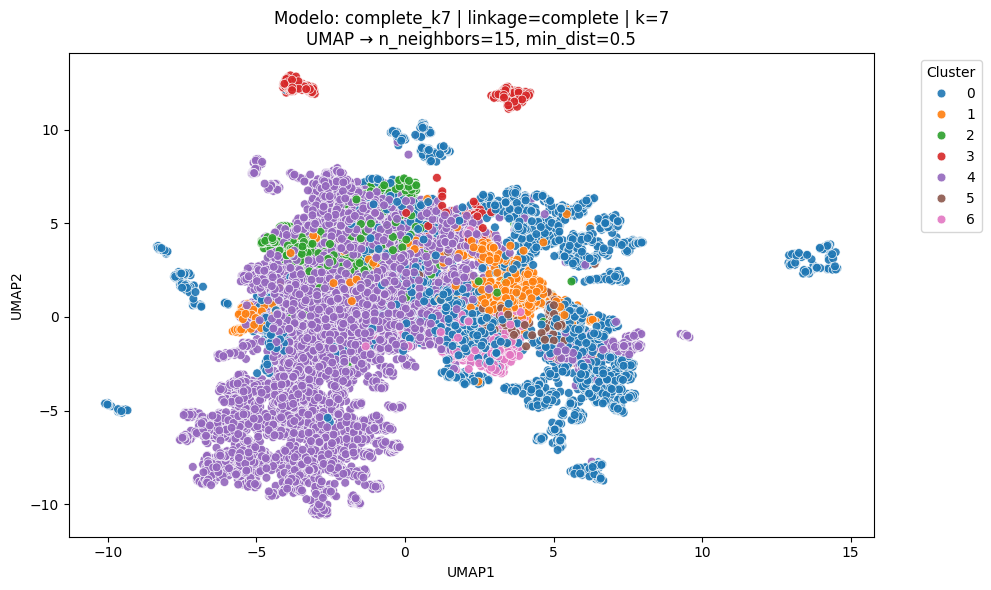

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



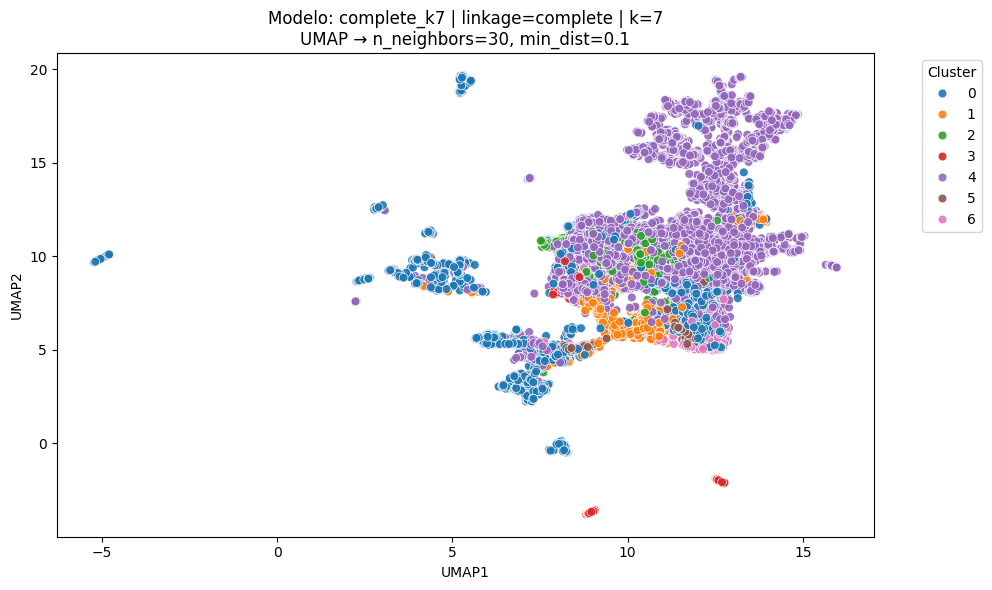

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



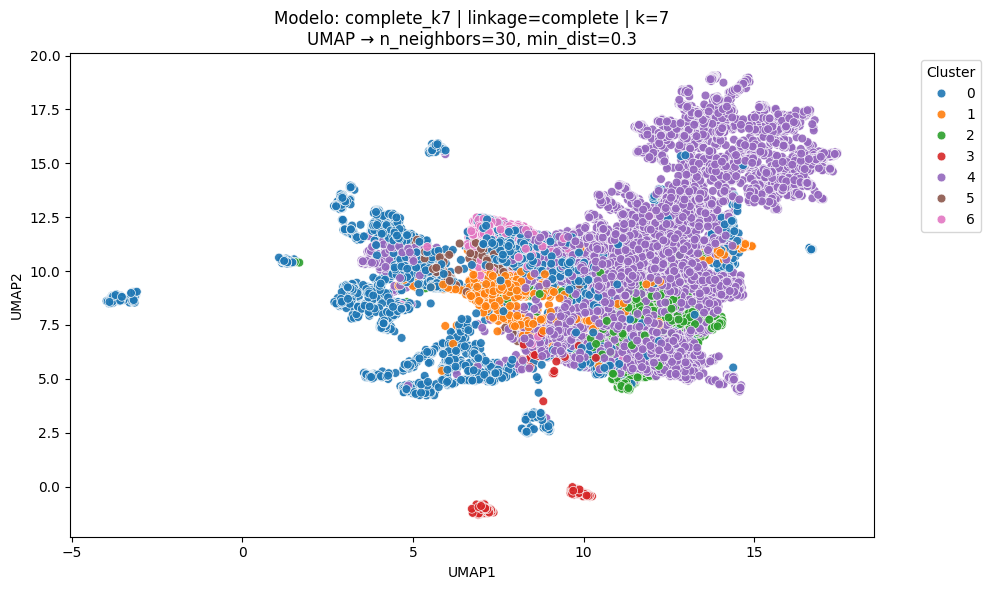

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



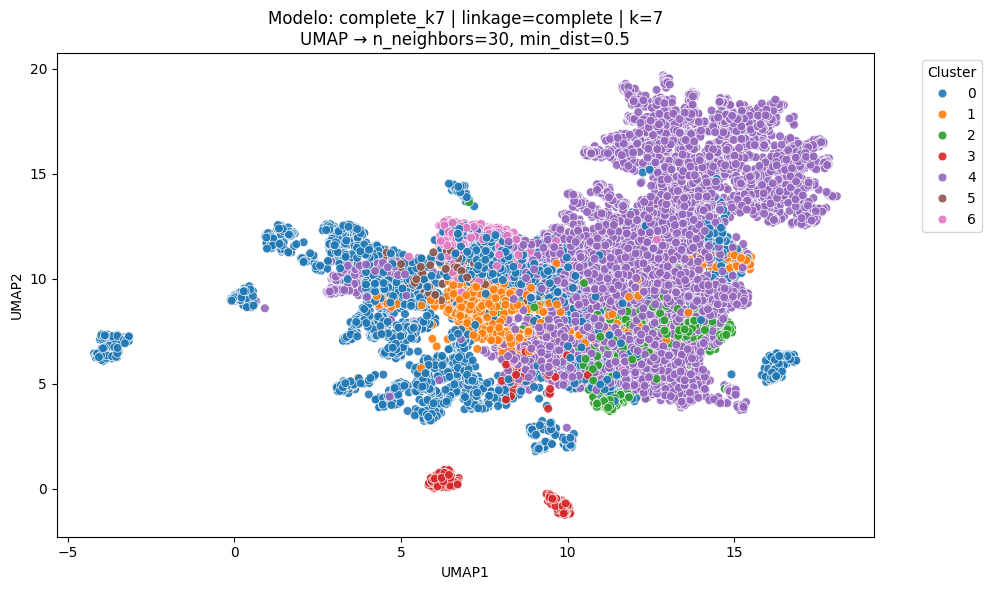

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



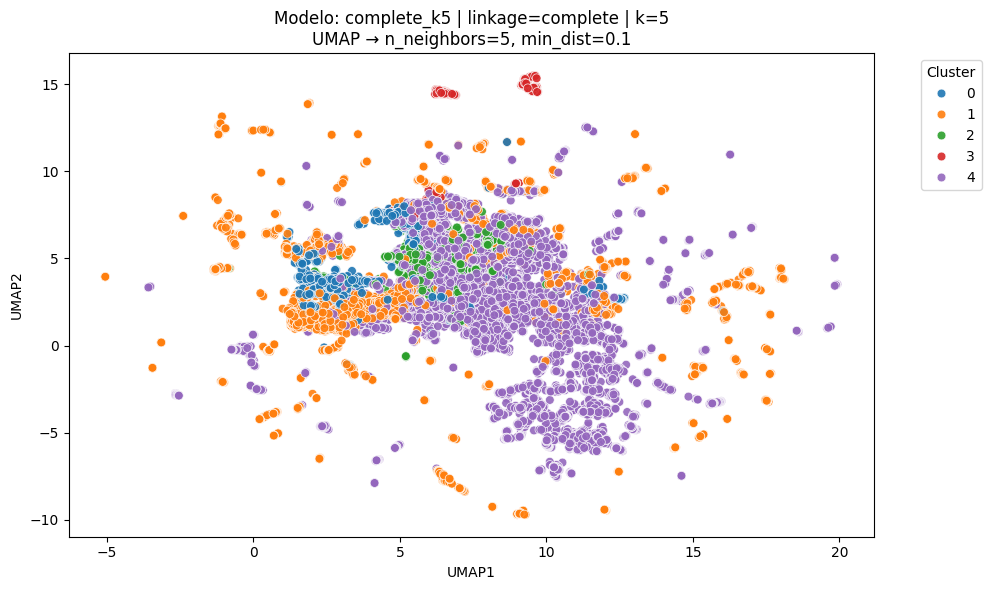

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



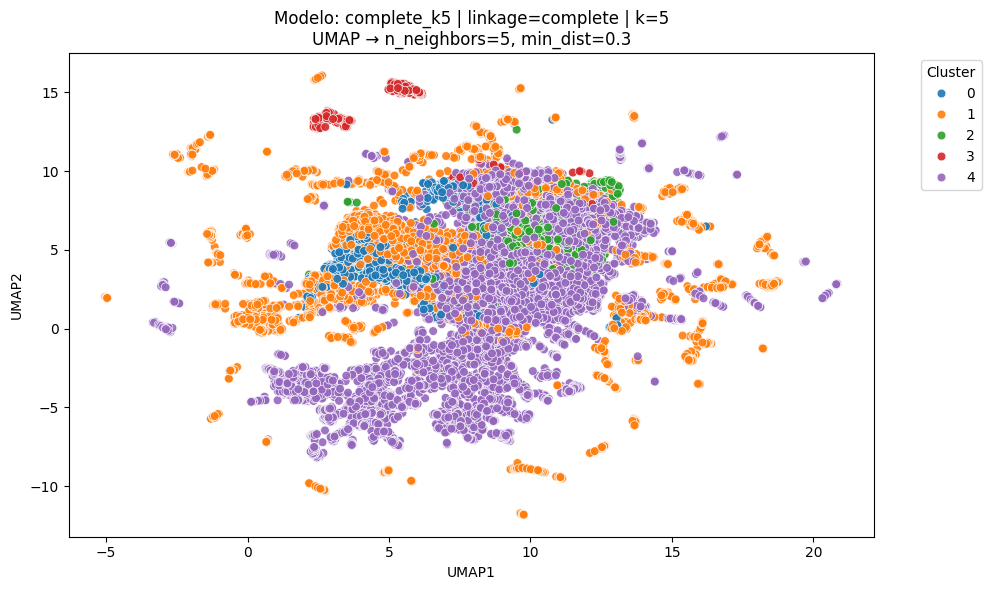

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



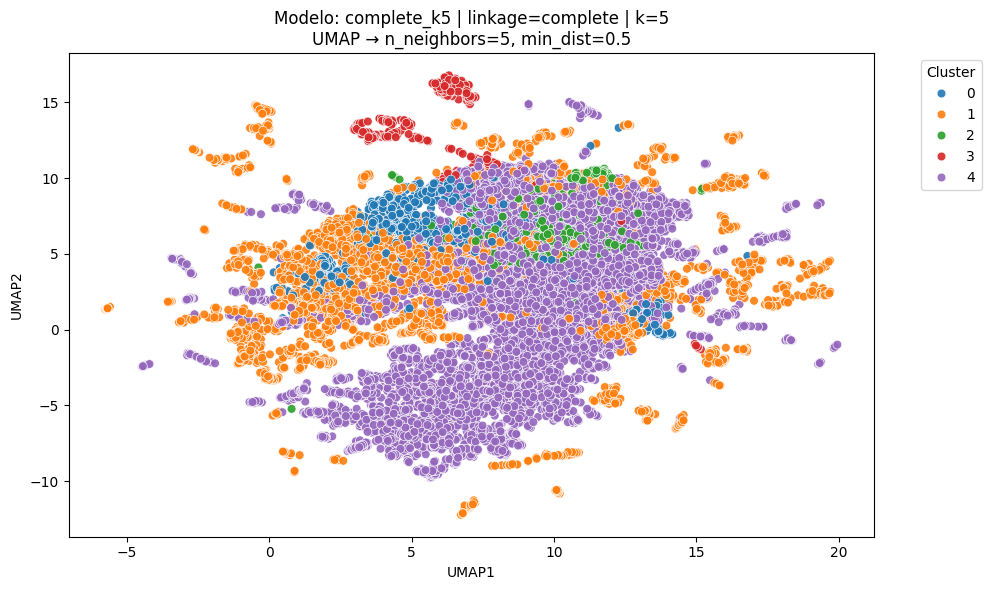

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



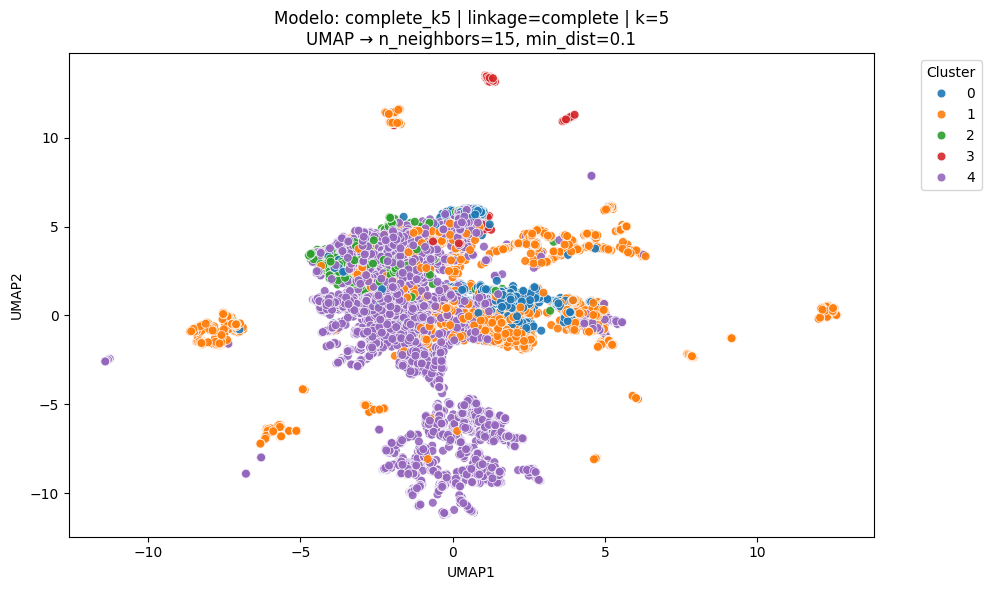

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



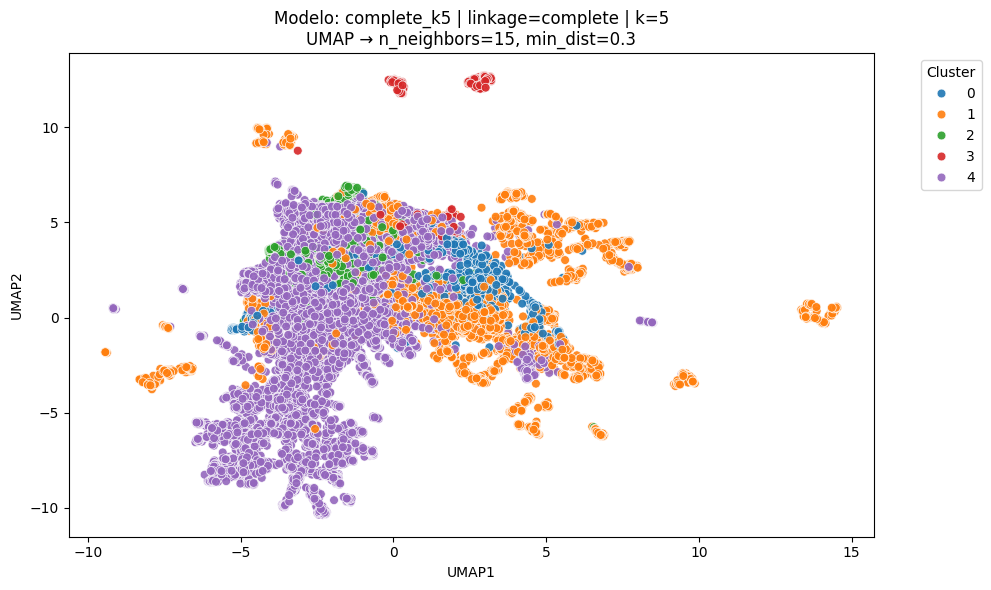

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



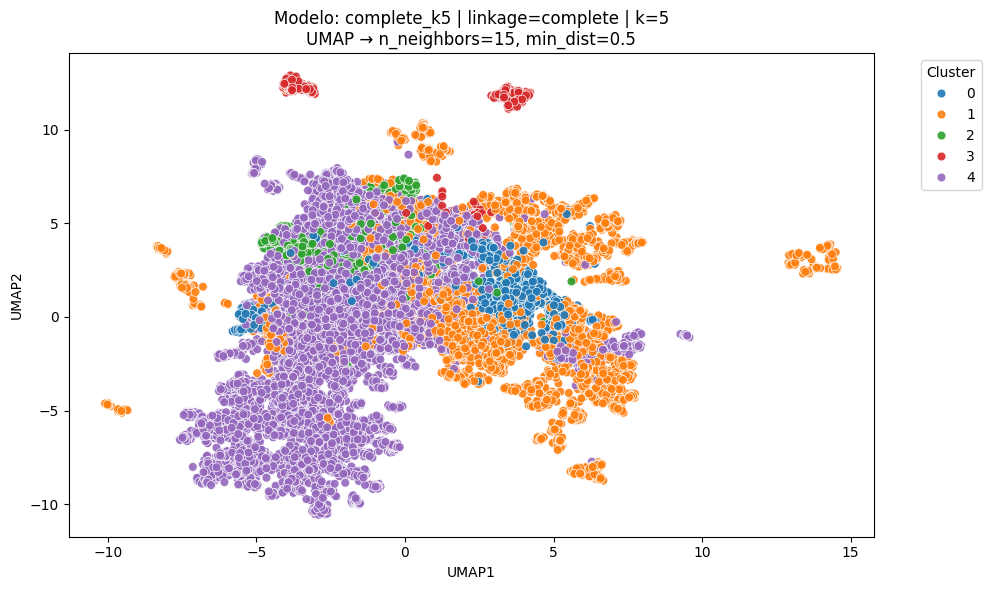

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



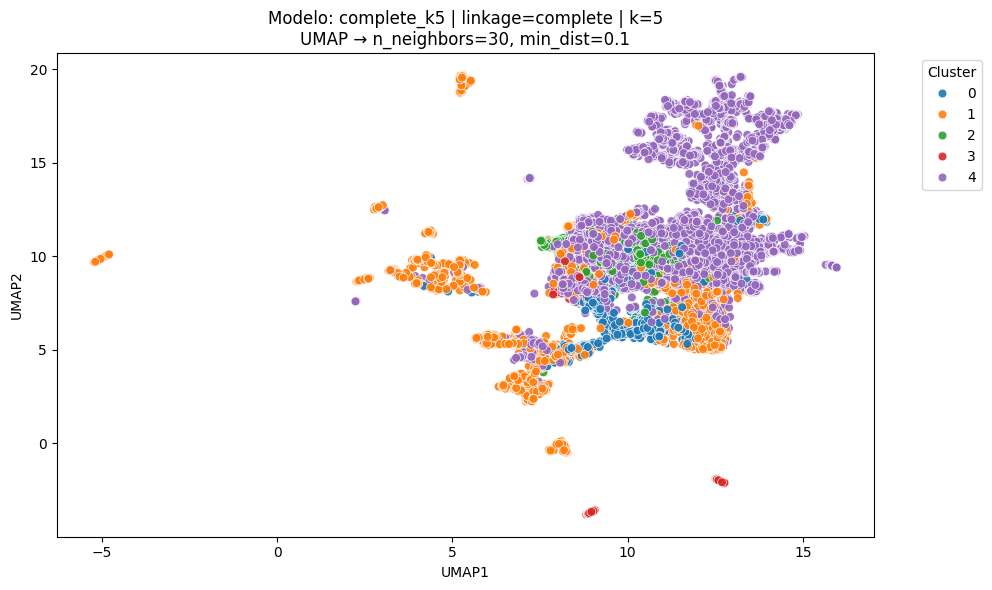

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



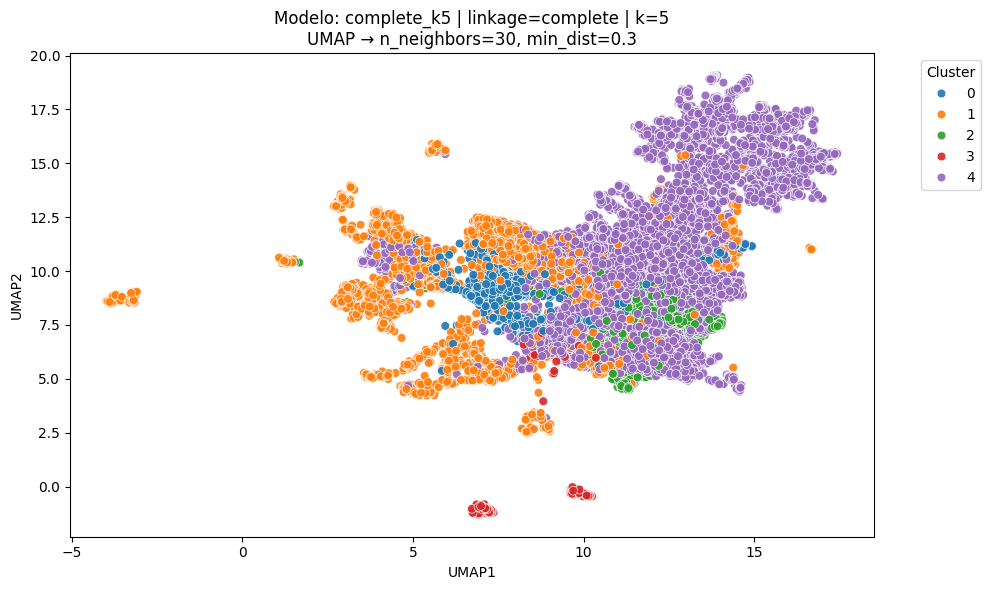

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



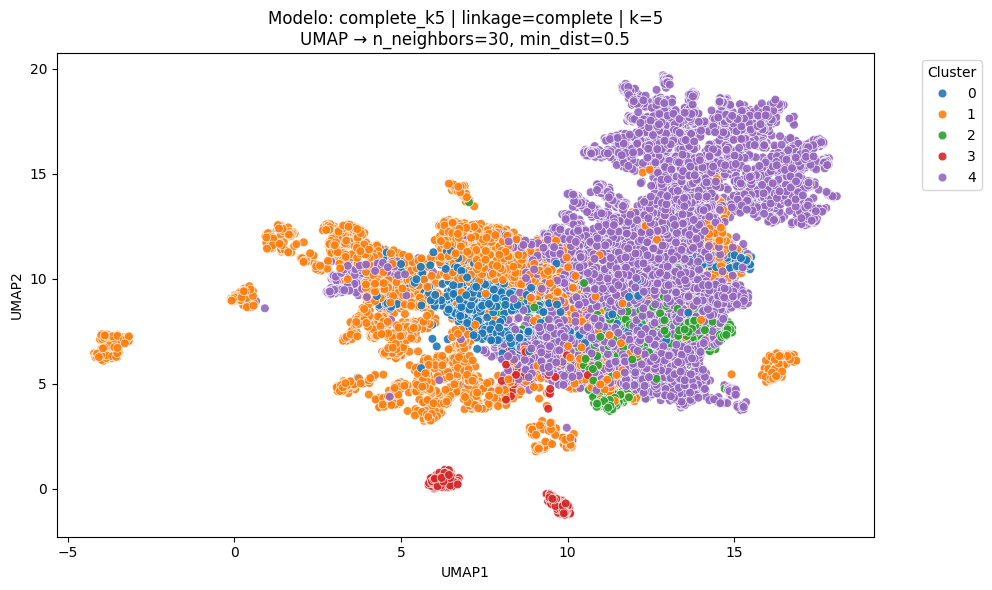

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



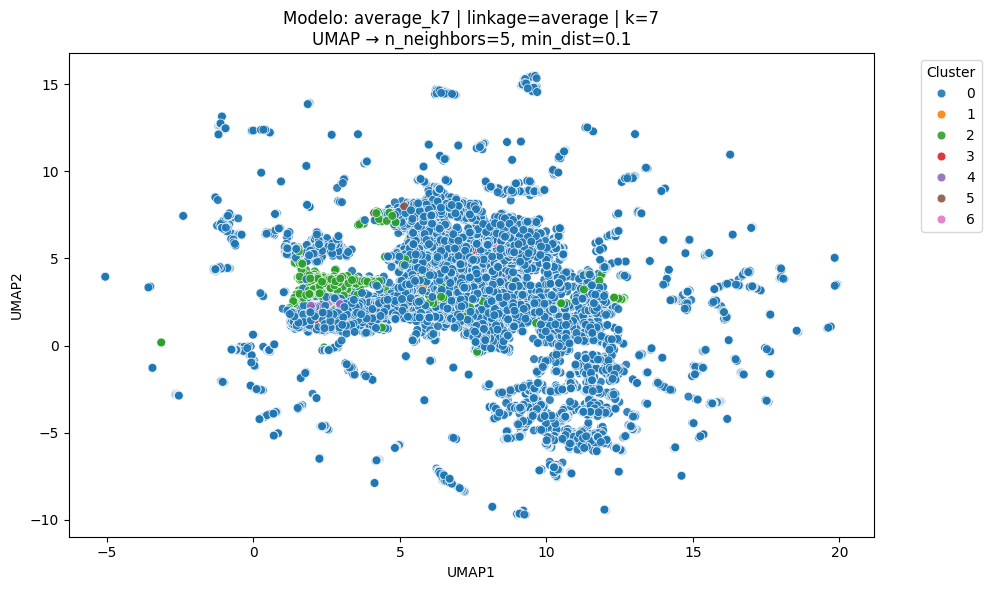

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



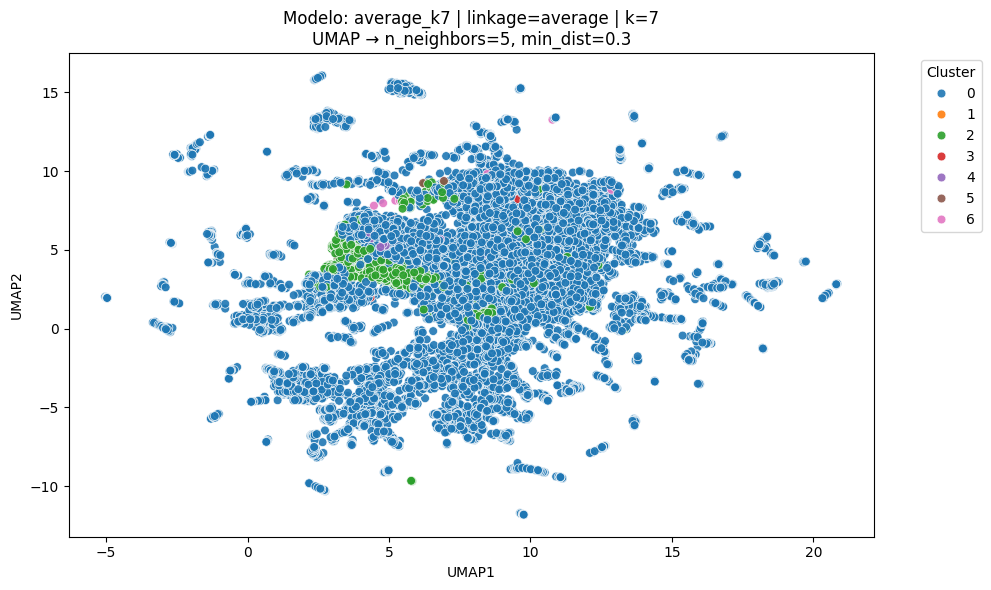

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



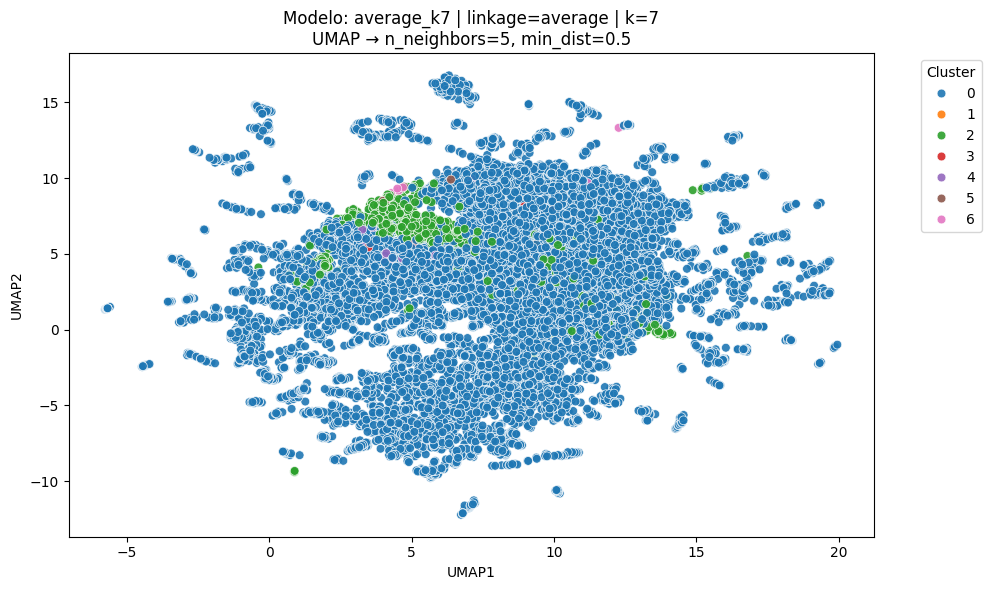

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



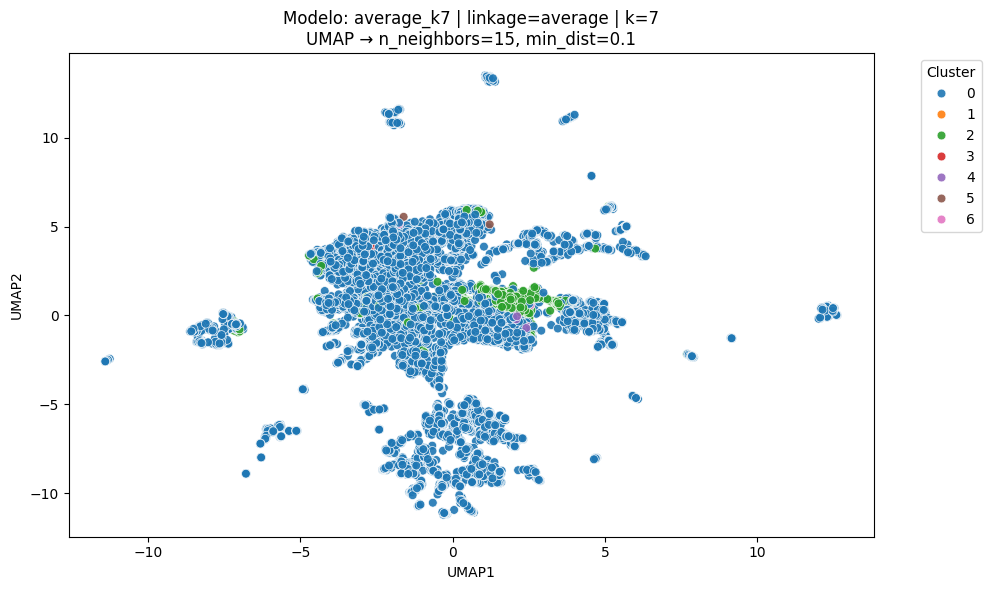

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



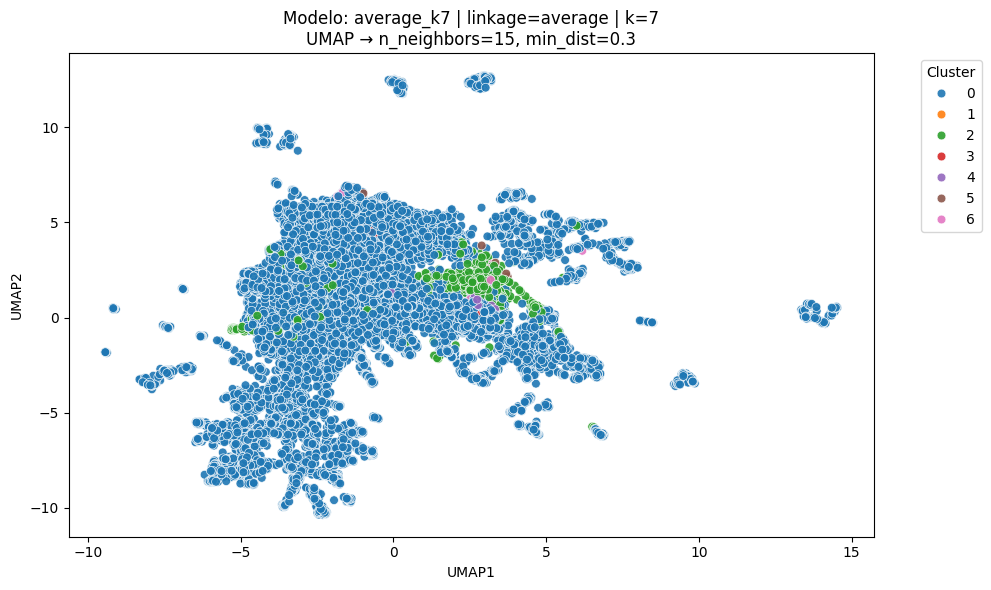

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



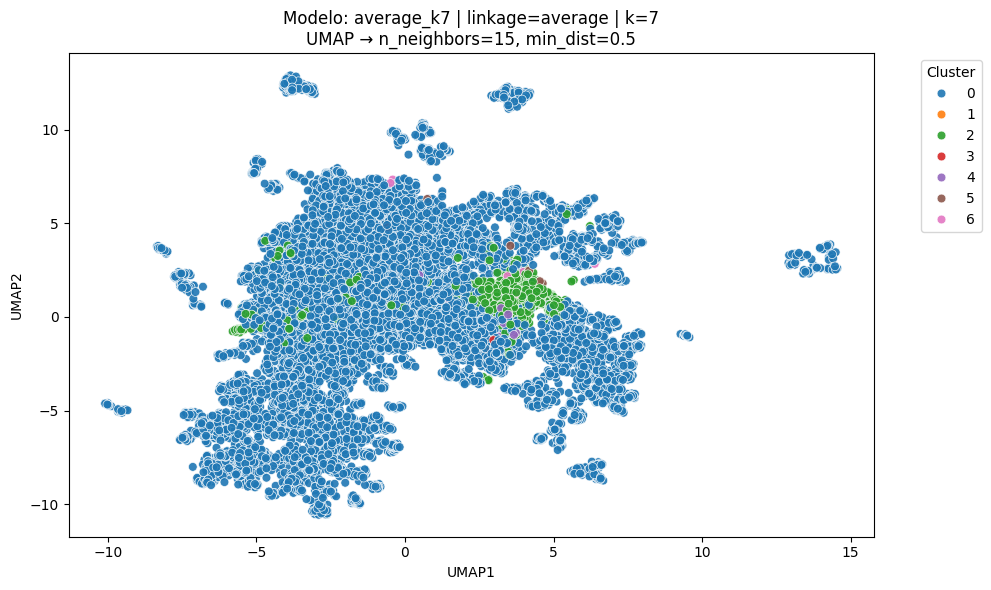

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



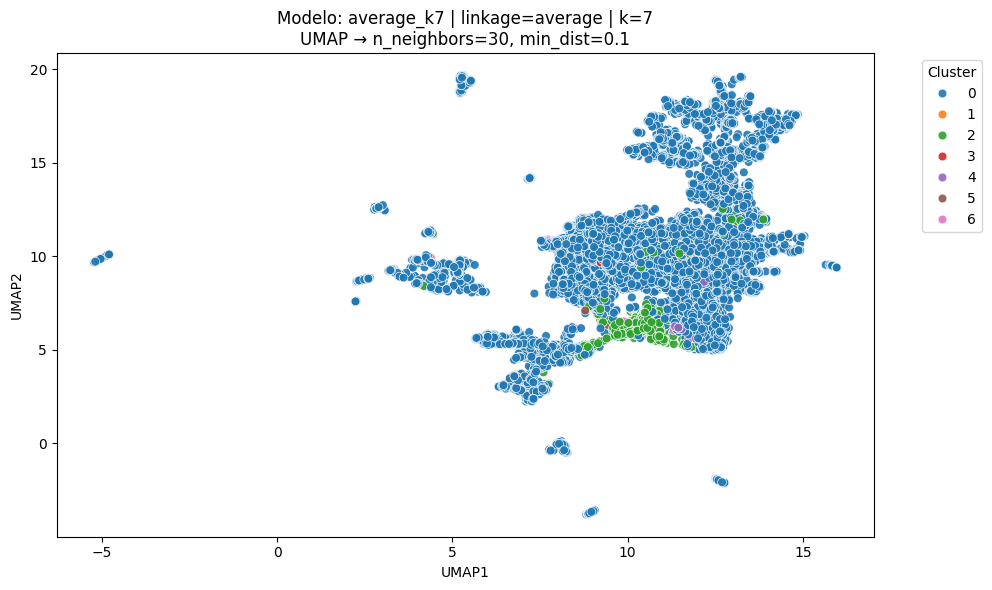

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



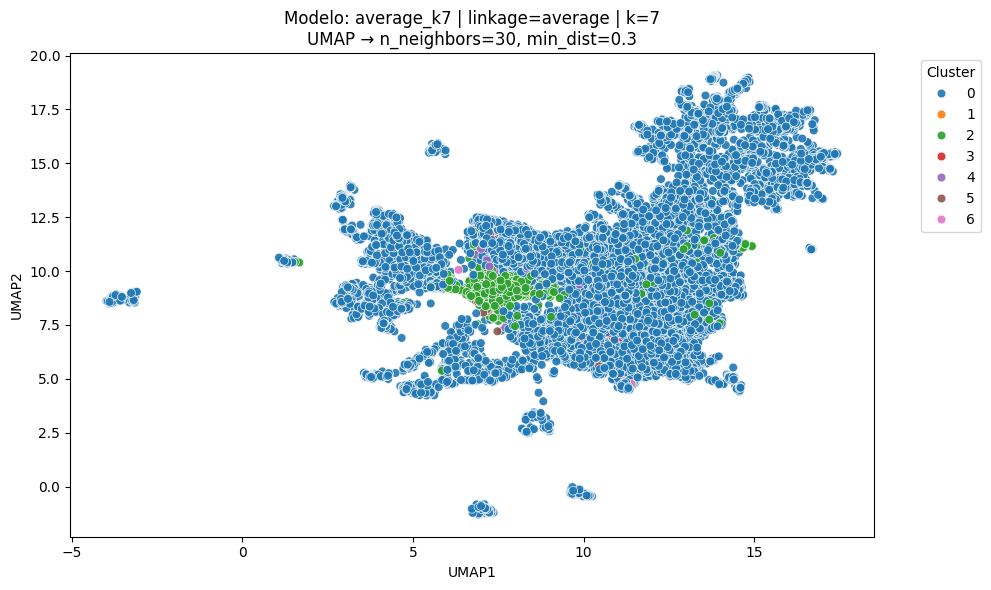

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\leopo\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



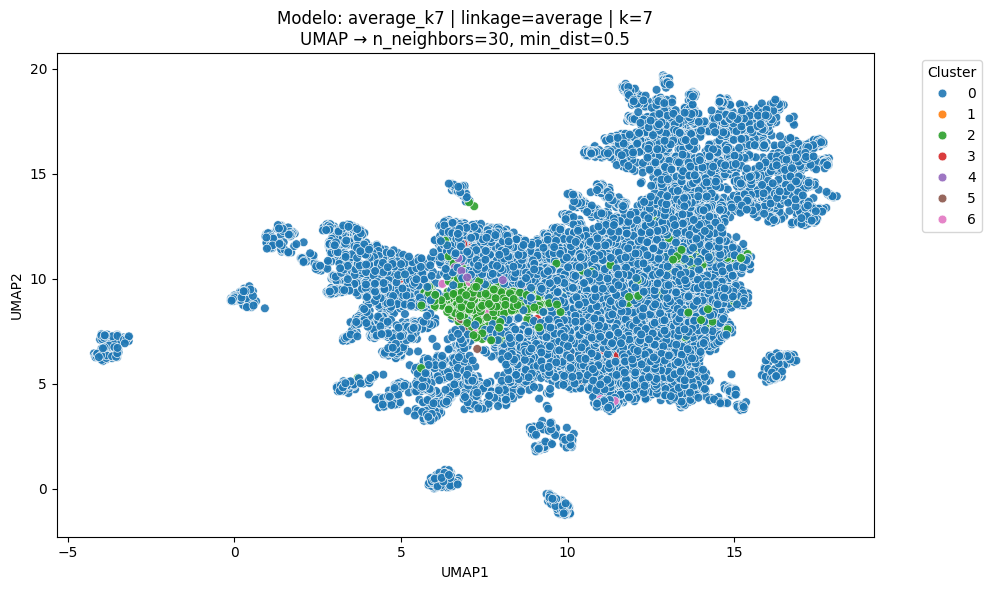

In [126]:
#Grafico los mejores con distintos parametros de UMAP
# 🔸 Tus top 3 modelos
top_modelos = consistencia.head(3)['modelo_1']

# 🔸 Parámetros UMAP a explorar
n_neighbors_list = [5, 15, 30]
min_dist_list = [0.1, 0.3, 0.5]

# 🔸 Recorremos los tres mejores modelos
for modelo in top_modelos:
    link, k = modelo.split('_k')
    n_clusters = int(k)

    # Clustering jerárquico
    cluster = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',
        linkage=link
    )
    labels = cluster.fit_predict(gower_dist)
    df['cluster'] = labels

    # Recorremos todas las combinaciones de parámetros UMAP
    for n in n_neighbors_list:
        for d in min_dist_list:
            reducer = umap.UMAP(
                n_neighbors=n,
                min_dist=d,
                metric='precomputed',
                random_state=42
            )
            embedding = reducer.fit_transform(gower_dist)

            df_umap = df.copy()
            df_umap['UMAP1'] = embedding[:, 0]
            df_umap['UMAP2'] = embedding[:, 1]

            # Gráfico
            plt.figure(figsize=(10, 6))
            sns.scatterplot(
                data=df_umap,
                x='UMAP1', y='UMAP2',
                hue='cluster',
                palette='tab10',
                s=40,
                alpha=0.9
            )
            plt.title(
                f"Modelo: {modelo} | linkage={link} | k={n_clusters}\n"
                f"UMAP → n_neighbors={n}, min_dist={d}"
            )
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster')
            plt.tight_layout()
            plt.show()
